In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from scipy.interpolate import RegularGridInterpolator
from astropy.cosmology import Planck18 as cosmo
from astropy import constants as con
from scipy.integrate import trapezoid

import pyccl as ccl

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams.update(
    {
        'text.usetex': False,
        'font.family': 'stixgeneral',
        'mathtext.fontset': 'stix',
    }
)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['image.origin'] = 'lower'
sns.set_context('talk') 
# sns.set(font_scale=1.5)
sns.set(font_scale=1.75)
sns.set_palette('colorblind')
sns.set_style('ticks')
# plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'sans'
plt.rcParams['mathtext.it'] = 'sans:italic'
plt.rcParams['mathtext.bf'] = 'sans:bold'
plt.rcParams['pdf.fonttype']=42

cmap = plt.get_cmap("rainbow_r"); colors = [cmap(i) for i in np.linspace(0, 1, 5)]

mpl.rcParams['axes.linewidth'] = 2   # thickness of the plot box
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.major.width'] = 2
mpl.rcParams['xtick.minor.width'] = 1
mpl.rcParams['ytick.minor.width'] = 1

mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['ytick.minor.size'] = 5

from sensitivity_funcs import *

In [2]:
default_dict = {
    'log_Mc': 13, 
    'Om0': cosmo.Om0, 
    'Ob0': cosmo.Ob0, 
    'h': cosmo.H0.value/100, 
    'sigma8': 0.8111, 
    'm_nu': 0.06, 
    'w0': -1, 
    'wa': 0
}
param_names = np.array(list(default_dict.keys()))
default_values = np.array(list(default_dict.values()))



In [3]:
nz_file_k = 'data/forecasts/source_LSSTY1.nz'
nz_file_g = 'data/forecasts/lens_LSSTY1.nz'
zbin_k_idx1, zbin_k_idx2 = 1, 5
zbin_g_idx1, zbin_g_idx2 = 1, 5
lmin, lmax = 1, 10000
n2d_mean_frb=0.00014
n2d_mean_g1=3.592707
n2d_mean_g2=2.252406
zmin, zmax = 0.0001, 3


cosmo_calc = CosmologyCalculator(H0_kms_per_Mpc=default_dict["h"]*100, 
                                 Ob0=default_dict["Ob0"], 
                                 Om0=default_dict["Om0"], 
                                 sigma8=default_dict["sigma8"], 
                                 m_nu=default_dict["m_nu"], 
                                 w0=default_dict["w0"], 
                                 wa=default_dict["wa"])


src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                              zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_k_idx1, zbin_k_idx2=zbin_k_idx2, 
                              zbin_g_idx1=zbin_g_idx1, zbin_g_idx2=zbin_g_idx2, 
                              n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)


In [4]:
z_grid = src_dist.z_grid
chi_grid = src_dist.chi
Hz_grid = src_dist.Hz
k_fields = np.geomspace(1e-4, 1e6, 1000)
logk_grid = np.log10(k_fields)
ells = np.arange(lmin, lmax + 1)

def compute_Cell(W1, W2, z_P, P, b1=1, b2=1, z_grid=z_grid, chi_grid=chi_grid, Hz_grid=Hz_grid, logk_grid=logk_grid, ells=ells):
    """Compute angular power spectrum C_ell via Limber approximation."""
    pts_z = np.repeat(z_grid[None, :], len(ells), axis=0)
    k_grid = ((ells[:, None]+0.5) / chi_grid[None, :])
    pts_logk = np.log10(k_grid)
    pts_z = np.stack([pts_z.ravel(), pts_logk.ravel()], axis=-1)
    
    logP_interpolator = RegularGridInterpolator((z_P, np.log10(k_fields)), np.log10(P), bounds_error=False)
    logP_vals = logP_interpolator(pts_z).reshape(len(ells), len(z_grid))
    Pk_values_Mpc3 = (10.0**logP_vals)*b1*b2
    integrand_z = (W1[None, :] * W2[None, :] / chi_grid[None, :]**2) * Pk_values_Mpc3 * (c / Hz_grid[None, :])
    return trapezoid(integrand_z, z_grid, axis=1)

z_P, P_gg = precomputed_power_spectra("params_0", "gg")
z_P, P_gm = precomputed_power_spectra("params_0", "gm")
z_P, P_mm = precomputed_power_spectra("params_0", "mm")

C_ell_DD = compute_Cell(src_dist.W_DM_wt, src_dist.W_DM_wt, z_P, P_gg)

C_ell_kk = compute_Cell(src_dist.W_k_wt1, src_dist.W_k_wt1, z_P, P_mm)

C_ell_gg = compute_Cell(src_dist.W_g_wt1, src_dist.W_g_wt1, z_P, P_mm, b1=1.24, b2=1.24)

zmean_f = np.mean(np.random.choice(src_dist.z_grid, 10000, p=src_dist.dn2d_dz_frb/np.sum(src_dist.dn2d_dz_frb)))
DMhost_var = 100**2
sigma_e = 0.36769552621
    
var_DMfield = np.trapz(ells*C_ell_DD, ells)/(2*np.pi)
var_GALfield = np.trapz(ells*C_ell_gg, ells)/(2*np.pi)
var_KAPPAfield = np.trapz(ells*C_ell_kk, ells)/(2*np.pi)

N_DM = ((DMhost_var/((1+zmean_f)**2)) + (var_DMfield))/(src_dist.n2d_mean_frb)
N_g1 = (1+var_GALfield)/src_dist.n2d_mean_g1
N_k1 = ((sigma_e**2)/src_dist.n2d_mean_g1)/2



In [5]:
import BaryonForge as bfg

def return_data_vectors(log10M_max):
    cosmo_calc = CosmologyCalculator(H0_kms_per_Mpc=default_dict["h"]*100,
                                     Ob0=default_dict["Ob0"], 
                                     Om0=default_dict["Om0"], 
                                     sigma8=default_dict["sigma8"], 
                                     m_nu=default_dict["m_nu"], 
                                     w0=default_dict["w0"], 
                                     wa=default_dict["wa"])
    z_P, P_gm, P_gg, P_mm = power_spectra(cosmo_calc.cosmo, log10M_max=log10M_max)
    galaxy_bias = {1: 1.24, 2: 1.36, 3: 1.47, 4: 1.60, 5: 1.76}

    order = [11,21,31,41,51,22,32,42,52,33,43,53,44,54,55]

    shear_shear = {}
    for ij in order:
        zbin_idx1 = int((ij%100 - ij%10)/10)
        zbin_idx2 = ij%10
        src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                      zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_idx1, zbin_k_idx2=zbin_idx2, 
                                      zbin_g_idx1=zbin_g_idx1, zbin_g_idx2=zbin_g_idx2, 
                                      n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
        shear_shear[ij] = compute_Cell(src_dist.W_k_wt1, src_dist.W_k_wt2, z_P, P_mm, chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)
        
    galaxy_galaxy = {}
    for ij in order:
        zbin_idx1 = int((ij%100 - ij%10)/10)
        zbin_idx2 = ij%10
        src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                      zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_k_idx1, zbin_k_idx2=zbin_k_idx2, 
                                      zbin_g_idx1=zbin_idx1, zbin_g_idx2=zbin_idx2, 
                                      n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
        galaxy_galaxy[ij] = compute_Cell(src_dist.W_g_wt1, src_dist.W_g_wt2, z_P, P_mm, 
                                         b1=galaxy_bias[zbin_idx1], b2=galaxy_bias[zbin_idx2], chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)

    order = [11, 12, 13, 14, 15, 21, 22, 23, 24, 25, 31, 32, 33, 34, 35, 41, 42, 43, 44, 45, 51, 52, 53, 54, 55]

    shear_galaxy = {}
    for ij in order:
        zbin_idx1 = int((ij%100 - ij%10)/10)
        zbin_idx2 = ij%10
        src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                      zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_idx1, zbin_k_idx2=zbin_idx2, 
                                      zbin_g_idx1=zbin_idx2, zbin_g_idx2=zbin_idx2, 
                                      n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
        shear_galaxy[ij] = compute_Cell(src_dist.W_k_wt1, src_dist.W_g_wt1, z_P, P_mm, 
                                         b1=1, b2=galaxy_bias[zbin_idx2], chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)

    order = [11, 22, 33, 44, 55]  
    
    DM_galaxy = {}
    for ij in order:
        zbin_idx1 = int((ij%100 - ij%10)/10)
        src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                      zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_k_idx1, zbin_k_idx2=zbin_k_idx2, 
                                      zbin_g_idx1=zbin_idx1, zbin_g_idx2=zbin_g_idx2, 
                                      n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
        DM_galaxy[ij] = compute_Cell(src_dist.W_DM_wt, src_dist.W_g_wt1, z_P, P_gm, b1=galaxy_bias[zbin_idx1], chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)

    DM_shear = {}
    for ij in order:
        zbin_idx1 = int((ij%100 - ij%10)/10)
        src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                      zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_idx1, zbin_k_idx2=zbin_k_idx2, 
                                      zbin_g_idx1=zbin_g_idx1, zbin_g_idx2=zbin_g_idx2, 
                                      n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
        DM_shear[ij] = compute_Cell(src_dist.W_DM_wt, src_dist.W_k_wt1, z_P, P_gm, chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)
        
    DM_DM = {}
    src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
                                  zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_k_idx1, zbin_k_idx2=zbin_k_idx2, 
                                  zbin_g_idx1=zbin_g_idx1, zbin_g_idx2=zbin_g_idx2, 
                                  n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
    DM_DM[0] = compute_Cell(src_dist.W_DM_wt, src_dist.W_DM_wt, z_P, P_gg, chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)
    
    return {"shear_shear": shear_shear, 
            "galaxy_galaxy": galaxy_galaxy, 
            "shear_galaxy": shear_galaxy, 
            "DM_galaxy": DM_galaxy, 
            "DM_shear": DM_shear, 
            "DM_DM": DM_DM}


logMmaxs = np.linspace(10, 16, 100)

# from joblib import Parallel, delayed
# def process_index(i):
#     data_vectors = return_data_vectors(logMmaxs[i])
#     filename = "data/forecasts/precomputed_data_vectors/data_vectors_logMmax{}_1h.npz".format(round(logMmaxs[i], 2))
#     np.savez_compressed(
#         filename,
#         shear_shear=data_vectors["shear_shear"],
#         galaxy_galaxy=data_vectors["galaxy_galaxy"],
#         shear_galaxy=data_vectors["shear_galaxy"],
#         DM_galaxy=data_vectors["DM_galaxy"],
#         DM_shear=data_vectors["DM_shear"],
#         DM_DM=data_vectors["DM_DM"]
#     )
#     return i

# results = Parallel(n_jobs=5)(
#     delayed(process_index)(i)
#     for i in tqdm(range(100))
# )




In [6]:
def return_Cell_integrand(W1, W2, z_P, P, b1=1, b2=1, z_grid=z_grid, chi_grid=chi_grid, Hz_grid=Hz_grid, logk_grid=logk_grid, ells=ells):
    """Compute angular power spectrum C_ell via Limber approximation."""
    pts_z = np.repeat(z_grid[None, :], len(ells), axis=0)
    k_grid = ((ells[:, None]+0.5) / chi_grid[None, :])
    pts_logk = np.log10(k_grid)
    pts_z = np.stack([pts_z.ravel(), pts_logk.ravel()], axis=-1)
    
    logP_interpolator = RegularGridInterpolator((z_P, np.log10(k_fields)), np.log10(P), bounds_error=False, fill_value=None)
    logP_vals = logP_interpolator(pts_z).reshape(len(ells), len(z_grid)) # ; logP_vals[np.isnan(logP_vals)] = -30
    Pk_values_Mpc3 = (10.0**logP_vals)*b1*b2
    integrand_z = (W1[None, :] * W2[None, :] / chi_grid[None, :]**2) * Pk_values_Mpc3 * (c / Hz_grid[None, :])
    
    k_array = 10**np.linspace(-2, 2, 100)
    chi_ellk = (ells[:, None]+0.5) / k_array[None, :] # Mpc

    n_k = len(k_array); n_ell = len(ells)
    z_ellk = np.interp(chi_ellk.ravel(), chi_grid, z_grid).reshape(n_ell, n_k)
    pts_k_integrand = np.stack([z_ellk.ravel(), np.log10(k_array.repeat(n_ell, axis=0).ravel())], axis=-1)
    
    W1_ellk = np.interp(chi_ellk.ravel(), chi_grid, W1).reshape(n_ell, n_k)
    W2_ellk = np.interp(chi_ellk.ravel(), chi_grid, W2).reshape(n_ell, n_k)
    logP_vals = logP_interpolator(pts_k_integrand).reshape(n_ell, n_k)
    Pk_values_Mpc3 = (10.0**logP_vals)
    integrand_k = (W1_ellk * W2_ellk / (ells + 0.5)[:, None]) * Pk_values_Mpc3
        
    return np.array(integrand_z), np.array(integrand_k)


# z_P, P_gm, P_gg, P_mm = power_spectra(cosmo_calc.cosmo, log10M_max=16)
# galaxy_bias = {1: 1.24, 2: 1.36, 3: 1.47, 4: 1.60, 5: 1.76}

# order = [11,21,31,41,51,22,32,42,52,33,43,53,44,54,55]

# shear_shear_zintegrand, shear_shear_kintegrand = {}, {}
# for k in tqdm(range(len(order))):
#     ij = order[k]
#     zbin_idx1 = int((ij%100 - ij%10)/10)
#     zbin_idx2 = ij%10
#     src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
#                                   zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_idx1, zbin_k_idx2=zbin_idx2, 
#                                   zbin_g_idx1=zbin_g_idx1, zbin_g_idx2=zbin_g_idx2, 
#                                   n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
#     output = return_Cell_integrand(src_dist.W_k_wt1, src_dist.W_k_wt1, z_P, P_mm, chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)
#     shear_shear_zintegrand[ij] = output[0]
#     shear_shear_kintegrand[ij] = output[1]

# galaxy_galaxy_zintegrand, galaxy_galaxy_kintegrand = {}, {}
# for k in tqdm(range(len(order))):
#     ij = order[k]
#     zbin_idx1 = int((ij%100 - ij%10)/10)
#     zbin_idx2 = ij%10
#     src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
#                                   zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_k_idx1, zbin_k_idx2=zbin_k_idx2, 
#                                   zbin_g_idx1=zbin_idx1, zbin_g_idx2=zbin_idx2, 
#                                   n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
#     output = return_Cell_integrand(src_dist.W_g_wt1, src_dist.W_g_wt1, z_P, P_mm, b1=galaxy_bias[zbin_k_idx1], b2=galaxy_bias[zbin_k_idx2], chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)
#     galaxy_galaxy_zintegrand[ij] = output[0]
#     galaxy_galaxy_kintegrand[ij] = output[1]
    
# order = [11, 12, 13, 14, 15, 21, 22, 23, 24, 25, 31, 32, 33, 34, 35, 41, 42, 43, 44, 45, 51, 52, 53, 54, 55]

# shear_galaxy_zintegrand, shear_galaxy_kintegrand = {}, {}
# for k in tqdm(range(len(order))):
#     ij = order[k]
#     zbin_idx1 = int((ij%100 - ij%10)/10)
#     zbin_idx2 = ij%10
#     src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
#                                   zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_idx1, zbin_k_idx2=zbin_k_idx2, 
#                                   zbin_g_idx1=zbin_idx2, zbin_g_idx2=zbin_g_idx2, 
#                                   n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
#     output = return_Cell_integrand(src_dist.W_k_wt1, src_dist.W_g_wt2, z_P, P_mm, b1=1, b2=galaxy_bias[zbin_k_idx2], chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)
#     shear_galaxy_zintegrand[ij] = output[0]
#     shear_galaxy_kintegrand[ij] = output[1]
    
# order = [11, 22, 33, 44, 55]  

# DM_galaxy_zintegrand, DM_galaxy_kintegrand = {}, {}

# for k in tqdm(range(len(order))):
#     ij = order[k]
#     zbin_idx1 = int((ij%100 - ij%10)/10)
#     src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
#                                   zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_k_idx1, zbin_k_idx2=zbin_k_idx2, 
#                                   zbin_g_idx1=zbin_idx1, zbin_g_idx2=zbin_g_idx2, 
#                                   n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
#     output = return_Cell_integrand(src_dist.W_DM_wt, src_dist.W_g_wt1, z_P, P_gm, b1=galaxy_bias[zbin_idx1], chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)
#     DM_galaxy_zintegrand[ij] = output[0]
#     DM_galaxy_kintegrand[ij] = output[1]
    
# DM_shear_zintegrand, DM_shear_kintegrand = {}, {}

# for k in tqdm(range(len(order))):
#     ij = order[k]
#     zbin_idx1 = int((ij%100 - ij%10)/10)
#     src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
#                                   zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_idx1, zbin_k_idx2=zbin_k_idx2, 
#                                   zbin_g_idx1=zbin_g_idx1, zbin_g_idx2=zbin_g_idx2, 
#                                   n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
#     output = return_Cell_integrand(src_dist.W_DM_wt, src_dist.W_k_wt1, z_P, P_gm, chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)
#     DM_shear_zintegrand[ij] = output[0]
#     DM_shear_kintegrand[ij] = output[1]
    
# DM_DM_zintegrand, DM_DM_kintegrand = {}, {}
# src_dist = SourceDistribution(cosmo_calc, nz_file_k=nz_file_k, nz_file_g=nz_file_g,
#                               zmin=zmin, zmax=zmax, zbin_k_idx1=zbin_k_idx1, zbin_k_idx2=zbin_k_idx2, 
#                               zbin_g_idx1=zbin_g_idx1, zbin_g_idx2=zbin_g_idx2, 
#                               n2d_mean_frb=n2d_mean_frb, n2d_mean_g1=n2d_mean_g1, n2d_mean_g2=n2d_mean_g2)
# output = return_Cell_integrand(src_dist.W_DM_wt, src_dist.W_DM_wt, z_P, P_gg, chi_grid=src_dist.chi, Hz_grid=src_dist.Hz)
# DM_DM_zintegrand[ij] = output[0]
# DM_DM_kintegrand[ij] = output[1]


# np.savez_compressed(
#     "data/forecasts/precomputed_data_vectors/data_vectors_zkintegrand_1h.npz",
#     shear_shear_zintegrand=shear_shear_zintegrand,
#     shear_shear_kintegrand=shear_shear_kintegrand,
#     galaxy_galaxy_zintegrand=galaxy_galaxy_zintegrand, 
#     galaxy_galaxy_kintegrand=galaxy_galaxy_kintegrand,
#     shear_galaxy_zintegrand=shear_galaxy_zintegrand, 
#     shear_galaxy_kintegrand=shear_galaxy_kintegrand,
#     DM_galaxy_zintegrand=DM_galaxy_zintegrand, 
#     DM_galaxy_kintegrand=DM_galaxy_kintegrand,
#     DM_shear_zintegrand=DM_shear_zintegrand, 
#     DM_shear_kintegrand=DM_shear_kintegrand,
#     DM_DM_zintegrand=DM_DM_zintegrand, 
#     DM_DM_kintegrand=DM_DM_kintegrand
# )


data_vectors_zkintegrand = np.load("data/forecasts/precomputed_data_vectors/data_vectors_zkintegrand_1h.npz", allow_pickle=True)

shear_shear_zintegrand=data_vectors_zkintegrand["shear_shear_zintegrand"]
shear_shear_kintegrand=data_vectors_zkintegrand["shear_shear_kintegrand"]
galaxy_galaxy_zintegrand=data_vectors_zkintegrand["galaxy_galaxy_zintegrand"]
galaxy_galaxy_kintegrand=data_vectors_zkintegrand["galaxy_galaxy_kintegrand"]
shear_galaxy_zintegrand=data_vectors_zkintegrand["shear_galaxy_zintegrand"]
shear_galaxy_kintegrand=data_vectors_zkintegrand["shear_galaxy_kintegrand"]
DM_galaxy_zintegrand=data_vectors_zkintegrand["DM_galaxy_zintegrand"]
DM_galaxy_kintegrand=data_vectors_zkintegrand["DM_galaxy_kintegrand"]
DM_shear_zintegrand=data_vectors_zkintegrand["DM_shear_zintegrand"]
DM_shear_kintegrand=data_vectors_zkintegrand["DM_shear_kintegrand"]
DM_DM_zintegrand=data_vectors_zkintegrand["DM_DM_zintegrand"]
DM_DM_kintegrand=data_vectors_zkintegrand["DM_DM_kintegrand"]




In [7]:
def get_spectra(logMmax):
    data_vectors = np.load(f"data/forecasts/precomputed_data_vectors/data_vectors_logMmax{logMmax}_1h.npz", allow_pickle=True)
    spectra = []
    
    # Shear-Shear
    for key in (data_vectors["shear_shear"].item().keys()):
        spectra.append(data_vectors["shear_shear"].item()[key])

    # Galaxy-Galaxy
    for key in (data_vectors["galaxy_galaxy"].item().keys()):
        spectra.append(data_vectors["galaxy_galaxy"].item()[key])

    # Shear-Galaxy
    for key in (data_vectors["shear_galaxy"].item().keys()):
        spectra.append(data_vectors["shear_galaxy"].item()[key])

    # DM-Galaxy
    for key in (data_vectors["DM_galaxy"].item().keys()):
        spectra.append(data_vectors["DM_galaxy"].item()[key])

    # DM-Shear
    for key in (data_vectors["DM_shear"].item().keys()):
        spectra.append(data_vectors["DM_shear"].item()[key])

    # DM-DM
    for key in (data_vectors["DM_DM"].item().keys()):
        spectra.append(data_vectors["DM_DM"].item()[key])
    
    return np.array(spectra)


lmax_to_keep = 10000
dC_dlogM = []
for i in tqdm(range(len(logMmaxs))):
    dC_dlogM.append(get_spectra(round(logMmaxs[i], 2)))

dC_dlogM, _, _ = np.gradient(dC_dlogM, logMmaxs, [i for i in range(66)], ells, edge_order=0)
dC_dlogM = dC_dlogM[:, :, :lmax_to_keep]

dC_dz, dC_dk = [], []

for data in [shear_shear_zintegrand, 
             galaxy_galaxy_zintegrand,
             shear_galaxy_zintegrand, 
             DM_galaxy_zintegrand,
             DM_shear_zintegrand,
             DM_DM_zintegrand]:
    for key in data.item().keys():
        dC_dz.append(data.item()[key])
dC_dz = np.array(dC_dz)
dC_dz = dC_dz[:, :lmax_to_keep, :]    

for data in [shear_shear_kintegrand, 
             galaxy_galaxy_kintegrand,
             shear_galaxy_kintegrand, 
             DM_galaxy_kintegrand,
             DM_shear_kintegrand,
             DM_DM_kintegrand]:
    for key in data.item().keys():
        dC_dk.append(data.item()[key])
dC_dk = np.array(dC_dk)
dC_dk = dC_dk[:, :lmax_to_keep, :] 

# del shear_shear_zintegrand
# del shear_shear_kintegrand
# del galaxy_galaxy_zintegrand
# del galaxy_galaxy_kintegrand
# del shear_galaxy_zintegrand
# del shear_galaxy_kintegrand
# del DM_galaxy_zintegrand
# del DM_galaxy_kintegrand
# del DM_shear_zintegrand
# del DM_shear_kintegrand
# del DM_DM_zintegrand
# del DM_DM_kintegrand

k_array = 10**np.linspace(-2, 2, 100)

# Correct ordering
dC_dlogM_ = np.transpose(dC_dlogM, (2, 1, 0))   # (2000, 66, 100)
dC_dz_    = np.transpose(dC_dz,    (1, 0, 2))   # (2000, 66, 1000)
dC_dk_    = np.transpose(dC_dk,    (1, 0, 2))   # (2000, 66, 1000)

print(dC_dlogM_.shape)  # should be (2000, 66, 100)
print(dC_dz_.shape)     # should be (2000, 66, 1000)
print(dC_dk_.shape)     # should be (2000, 66, 100)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:52<00:00,  1.91it/s]


(10000, 66, 100)
(10000, 66, 1000)
(10000, 66, 100)


In [8]:
cov_blocks = np.load("data/forecasts/cov_blocks_1e4FRBs.npz", 
                     allow_pickle=True)["cov_blocks"]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:08<00:00, 1152.13it/s]


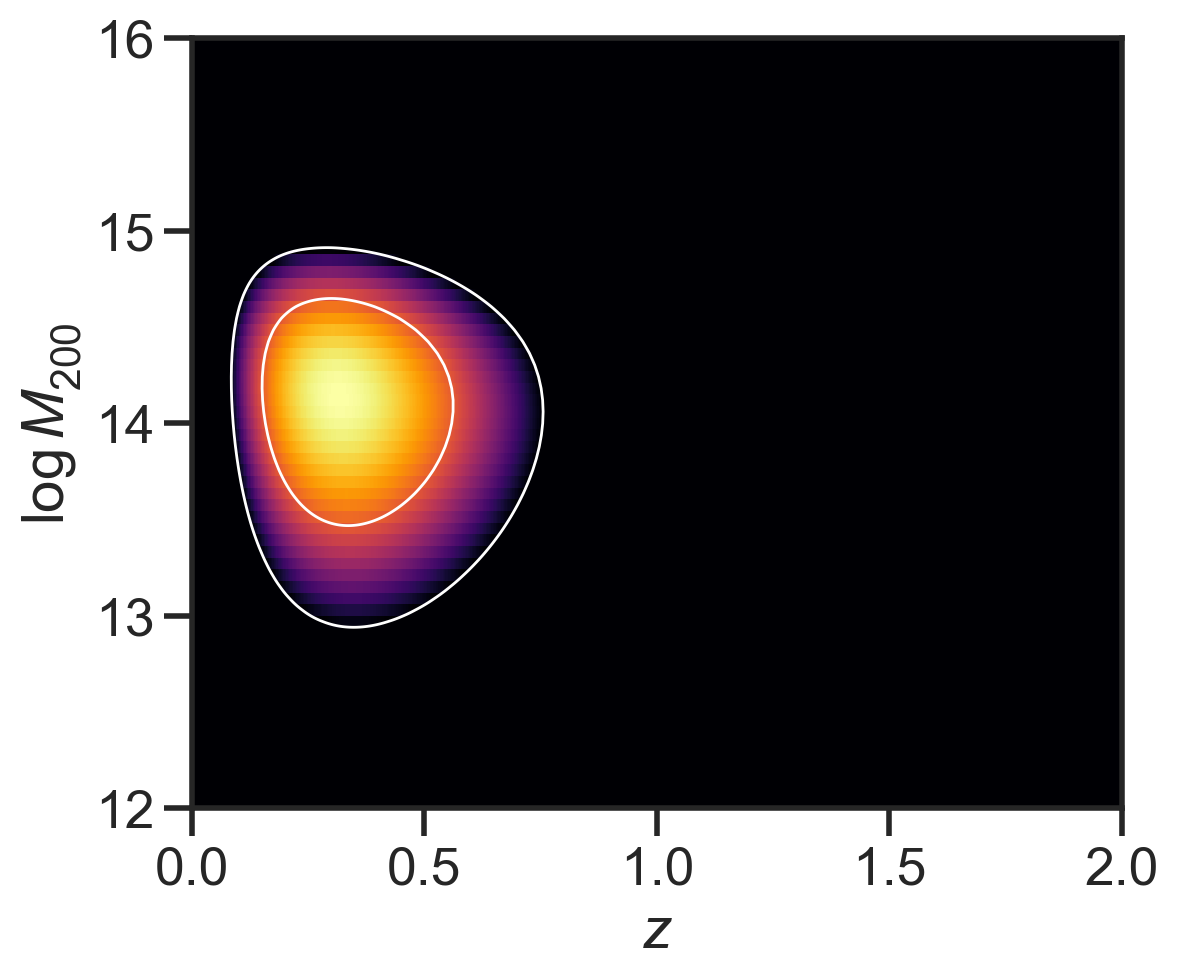

In [9]:
idx_min, idx_max = 0, 15
# 0, 15 # cosmic_shear
# 15, 30 # galaxy clustering
# 30, 55 # galaxy-galaxy lensing
# 55, 60 # DM x galaxy
# 60, 65 # DM x shear
# 65, 66 # DM x DM

S_total = np.zeros((100, 1000))
inv_cov_blocks = np.array([np.linalg.pinv(cov_blocks[i, idx_min:idx_max, idx_min:idx_max]) for i in range(len(cov_blocks))])

for ell in tqdm(range(lmax_to_keep)):
    A = dC_dlogM_[ell, idx_min:idx_max, :]      # (66, 100)
    B = dC_dz_[ell, idx_min:idx_max, :]         # (66, 1000)
    Cinv = inv_cov_blocks[ell]  # (66, 66)
    tmp = Cinv @ B          # (66, 1000)
    S_total += A.T @ tmp    # (100, 1000)

    
S_total[np.isnan(S_total)] = 1e-100
sensitivity = S_total/np.max(np.abs(S_total))
sensitivity[sensitivity <= 0] = 1e-10

fig, ax = plt.subplots(figsize=(6, 5))

cax = ax.pcolormesh(
    z_grid,
    logMmaxs,
    sensitivity,
    shading="nearest",
    cmap="inferno",
    norm=LogNorm(0.33, 1)
)

levels = np.array([0.33, 0.66])
Z, M = np.meshgrid(z_grid, logMmaxs)

ax.contour(Z, M, sensitivity, levels=levels,
           colors='white', linewidths=1.0)

ax.set_xlabel("$z$")
ax.set_ylabel(r"$\log M_\mathrm{200}$")

ax.set_xlim(0, 2)
ax.set_ylim(12, 16)

np.save("data/forecasts/sensitivity_LSST_cosmic_shear_MZ_lmax1e4_1h.npy", np.array([Z, M, sensitivity/np.max(sensitivity)]))


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 10077.02it/s]


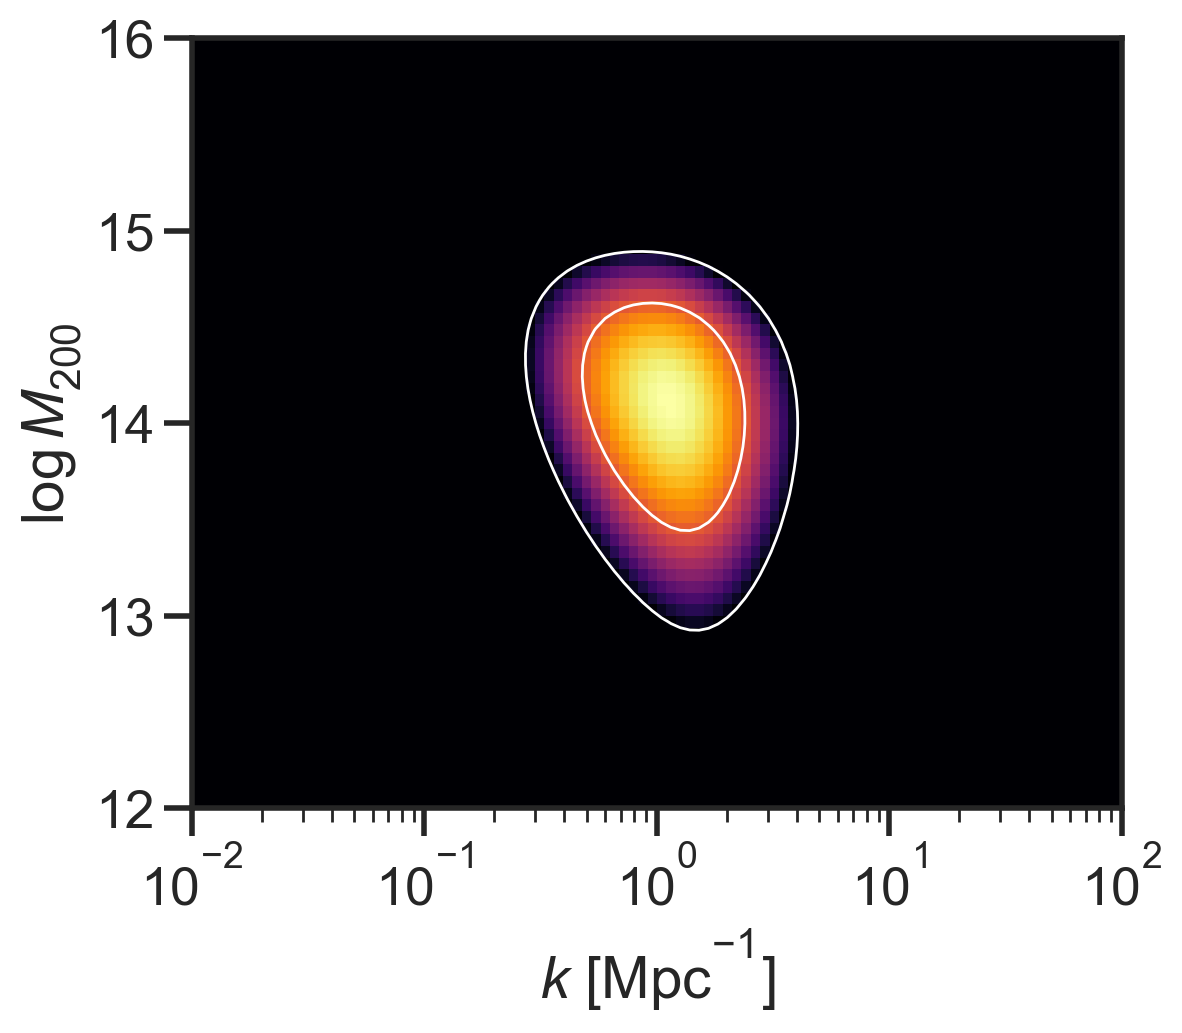

In [10]:
idx_min, idx_max = 0, 15

S_total = np.zeros((100, 100))
inv_cov_blocks = np.array([np.linalg.pinv(cov_blocks[i, idx_min:idx_max, idx_min:idx_max]) for i in range(len(cov_blocks))])

for ell in tqdm(range(lmax_to_keep)):
    A = dC_dlogM_[ell, idx_min:idx_max, :]      # (66, 100)
    B = dC_dk_[ell, idx_min:idx_max, :]         # (66, 1000)
    Cinv = inv_cov_blocks[ell]  # (66, 66)
    tmp = Cinv @ B          # (66, 1000)
    S_total += A.T @ tmp    # (100, 1000)

    
S_total[np.isnan(S_total)] = 1e-100
sensitivity = S_total/np.max(np.abs(S_total))
sensitivity[sensitivity <= 0] = 1e-10

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.pcolormesh(k_array, logMmaxs, sensitivity, shading="nearest", cmap="inferno", norm=LogNorm(0.33, 1))

levels = np.array([0.33, 0.66])
K, M = np.meshgrid(k_array, logMmaxs)
contours = ax.contour(K, M, sensitivity, levels=levels, colors='white', linewidths=1.0)

ax.set_xlabel("$k~[\mathrm{Mpc}^{-1}]$")
ax.set_ylabel(r"$\log M_\mathrm{200}$")

ax.set_ylim(12, 16)
ax.set_xlim(1e-2, 1e2)
ax.set_xscale('log')

np.save("data/forecasts/sensitivity_LSST_cosmic_shear_MK_lmax1e4_1h.npy", np.array([K, M, sensitivity/np.max(sensitivity)]))


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


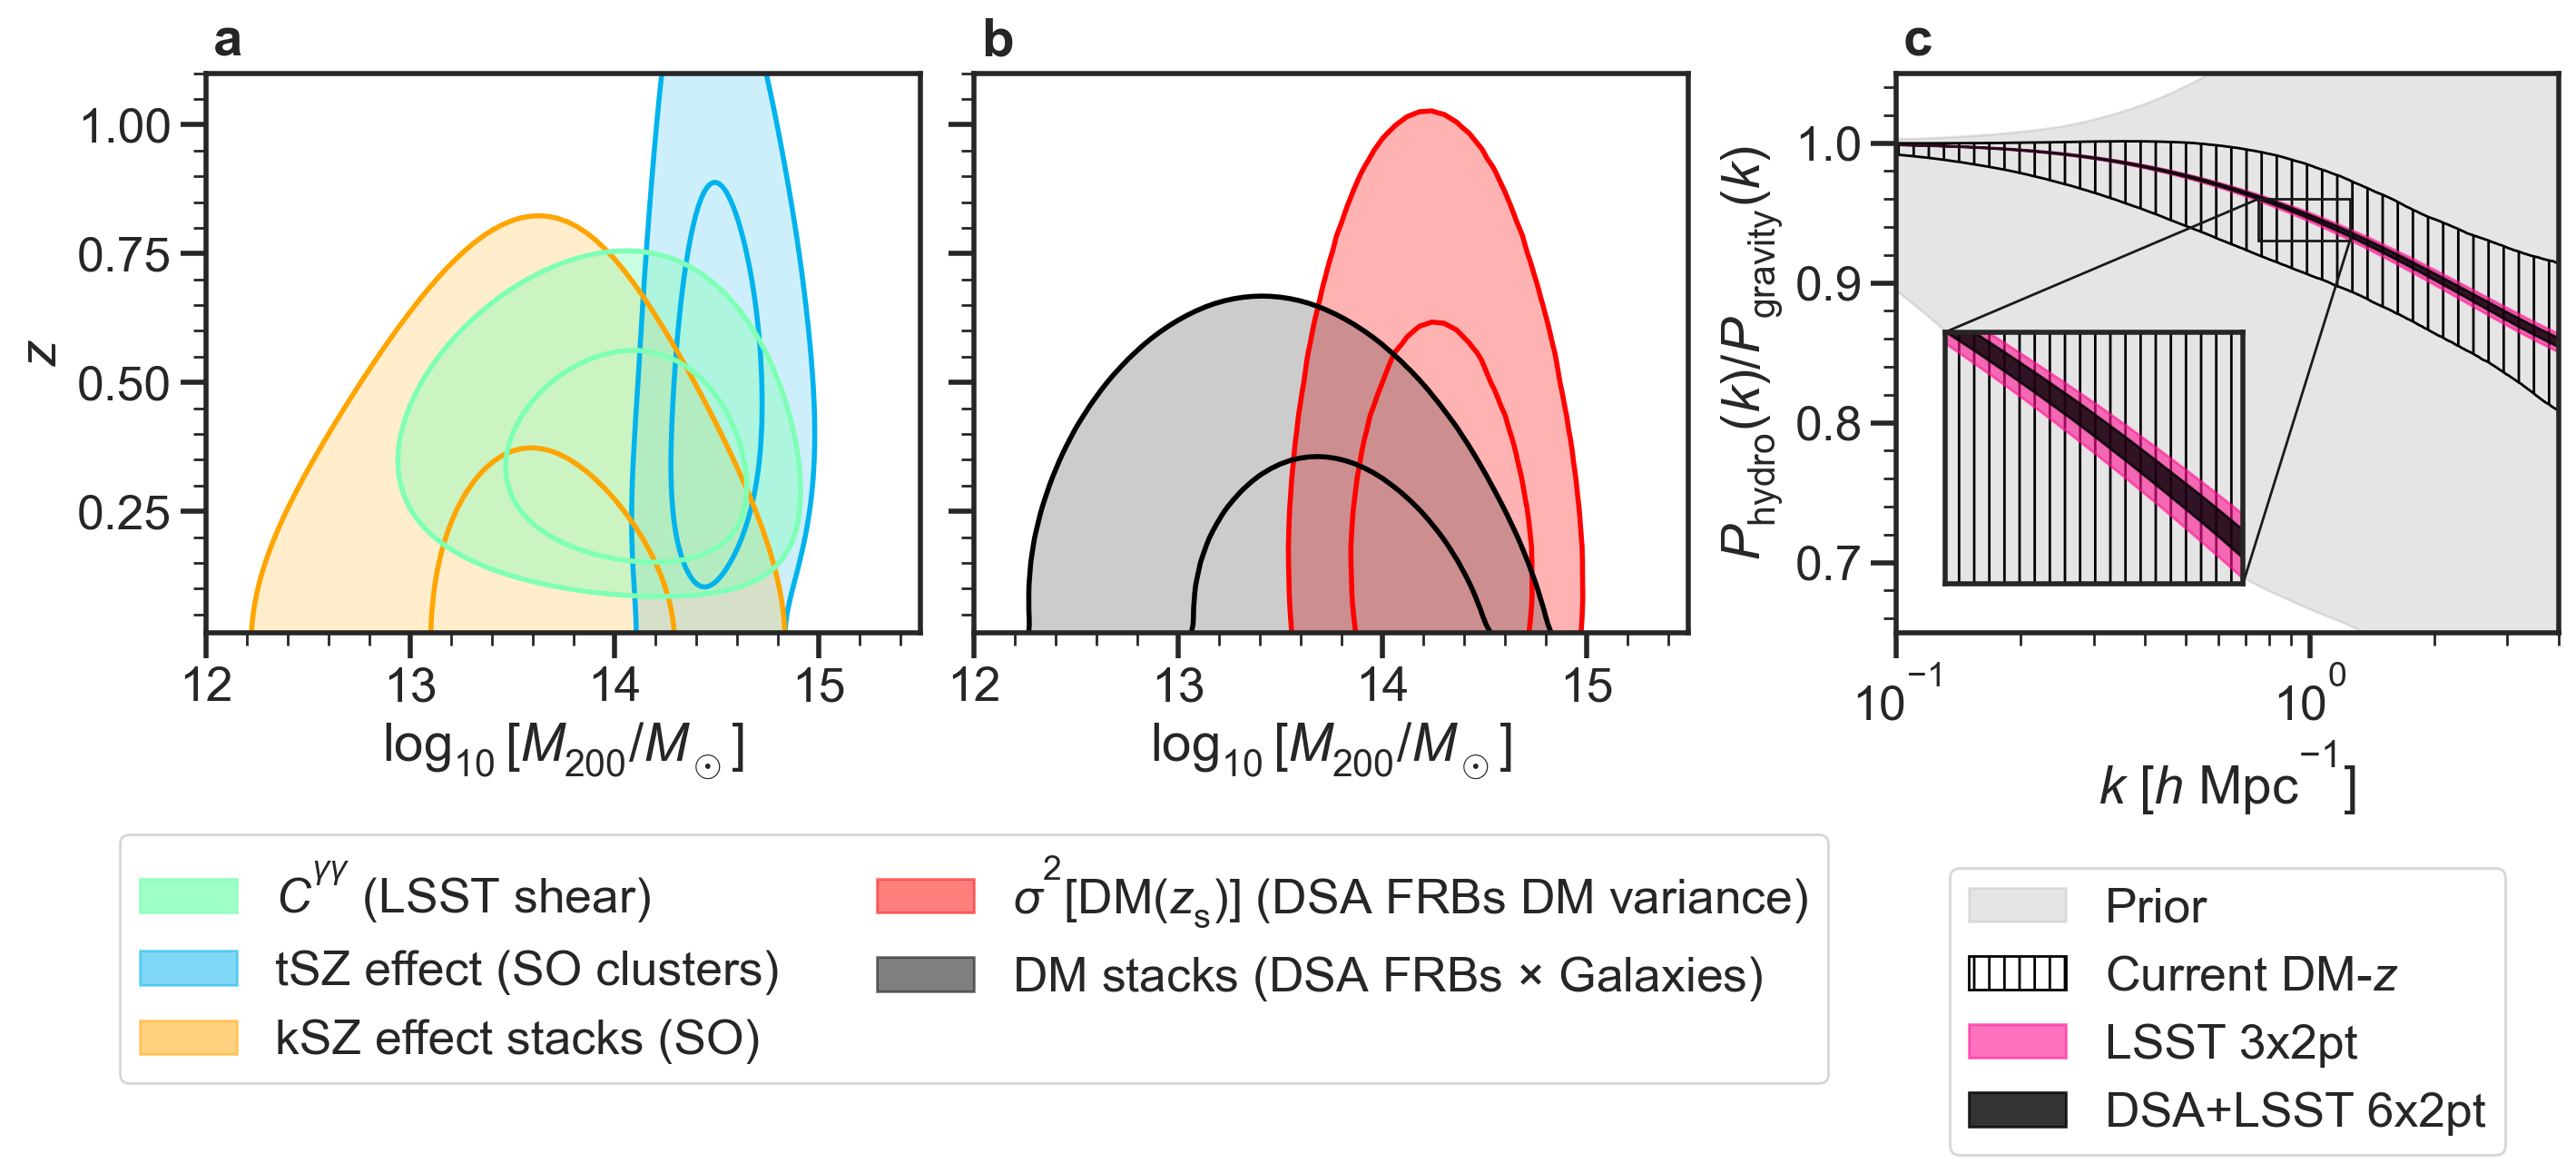

In [11]:
mpl.rcParams['axes.linewidth'] = 2   # thickness of the plot box
mpl.rcParams['xtick.major.width'] = 2; mpl.rcParams['ytick.major.width'] = 2; mpl.rcParams['xtick.minor.width'] = 1; mpl.rcParams['ytick.minor.width'] = 1
mpl.rcParams['xtick.major.size'] = 10; mpl.rcParams['ytick.major.size'] = 10; mpl.rcParams['xtick.minor.size'] = 5; mpl.rcParams['ytick.minor.size'] = 5

fig, (ax2, ax1, ax3) = plt.subplots(1, 3, figsize=(16, 4))

ax1.fill_between([], [], [], color=colors[2],
                 label=r"$C^{\gamma\gamma}$ (LSST shear)",
                 alpha=0.75)

ax1.fill_between([], [], [], color=colors[3],
                 label="tSZ effect (SO clusters)",
                 alpha=0.5)

ax1.fill_between([], [], [], color="orange",
                 label="kSZ effect stacks (SO)",
                 alpha=0.5)


lmax = "1e4"
levels_main = np.array([0.33, 0.66, 1])
cmap = plt.get_cmap("rainbow_r")
colors = [cmap(i) for i in np.linspace(0, 1, 5)]

# =========================
# 1) FRB DM Variance
# =========================
Z, M, sensitivity = np.load(
    "data/forecasts/sensitivity_DSA2000FRBs_DMvar_MZ_1h.npy"
)

ax1.contour(M, Z, sensitivity, levels=levels_main,
            colors=colors[0], linewidths=2)
ax1.contourf(M, Z, sensitivity, levels=levels_main,
             colors=colors[0], alpha=0.3)
ax1.fill_between([], [], [], color=colors[0],
                 label=r'$\sigma^2[\mathrm{DM}(z_\mathrm{s})]$ (DSA FRBs DM variance)',
                 alpha=0.5)

# =========================
# FRB Redshift Sampling
# =========================
z_pdf_grid = np.linspace(0, 5, 100)
pdf = z_pdf_grid**2 * np.exp(-3.5 * z_pdf_grid)
pdf = np.clip(pdf, 0, None)
pdf /= np.trapz(pdf, z_pdf_grid)

cdf = np.cumsum(pdf * np.gradient(z_pdf_grid))
cdf /= cdf[-1]

from scipy.interpolate import interp1d
inv_cdf = interp1d(cdf, z_pdf_grid,
                   bounds_error=False,
                   fill_value=(z_pdf_grid[0], z_pdf_grid[-1]))

z_samples = inv_cdf(np.random.rand(10000))

# =========================
# Halo Mass Function Setup
# =========================
from colossus.cosmology import cosmology
from colossus.lss import mass_function
from colossus.halo import mass_defs
from astropy.cosmology import Planck18 as cosmo

cosmology.setCosmology("planck18")

z_vals = np.linspace(0, 1.5, 100)
logM = np.linspace(11, 15.5, 100)
M = 10**logM
LOGM, Z_mesh = np.meshgrid(logM, z_vals)

# =========================
# 2) FRB DM Stacks
# =========================
dn_dMs_FRBs = []

for z in z_vals:
    dn_dlnM = mass_function.massFunction(
        M, z, mdef="200c", model="tinker08", q_out="dndlnM"
    )
    dn_dM = dn_dlnM / M
    weight = np.interp(z, z_pdf_grid, 1 - cdf)
    dn_dMs_FRBs.append(dn_dM * M**(4/3) * weight * M)

dn_dMs_FRBs = np.array(dn_dMs_FRBs)
sensitivity_FRBs = dn_dMs_FRBs / np.max(dn_dMs_FRBs)

ax1.contour(LOGM, Z_mesh, sensitivity_FRBs,
            levels=levels_main, colors="black", linewidths=2)
ax1.contourf(LOGM, Z_mesh, sensitivity_FRBs,
             levels=levels_main, colors="black", alpha=0.2)
ax1.fill_between([], [], [], color="black",
                 label=r"DM stacks (DSA FRBs $\times$ Galaxies)", alpha=0.5)

# =========================
# 3) Galaxy × FRB DM Cross
# =========================
# for file in [
#     f"data/forecasts/sensitivity_LSST_DSA2000_DMxgalaxy12_MZ_lmax1e4_1h.npy",
#     f"data/forecasts/sensitivity_LSST_DSA2000_DMxgalaxy345_MZ_lmax1e4_1h.npy"
# ]:
#     Z, M, sensitivity = np.load(file)
#     ax1.contour(M, Z, sensitivity,
#                 levels=levels_main, colors="k", linewidths=2)
#     ax1.contourf(M, Z, sensitivity,
#                  levels=levels_main, colors="k", alpha=0.2)

# ax1.fill_between([], [], [], color="k",
#                  label=r"$C^{g\mathcal{D}}$ (LSST galaxies x DSA FRB DMs)",
#                  alpha=0.5)

# =========================
# 4) Simons Observatory tSZ
# =========================
SO_cat = np.load(
    "data/forecasts/catalogue_so_simulated_0.npy",
    allow_pickle=True
)[0]

logM_SO = np.log10(SO_cat["M"] * 1e14)
SO_z = SO_cat["z"]

from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter

points = np.vstack([logM_SO, SO_z])
kde = gaussian_kde(points)

logM_grid = np.linspace(logM_SO.min(), logM_SO.max(), 200)
z_grid = np.linspace(SO_z.min(), SO_z.max(), 200)
logM_mesh, z_mesh = np.meshgrid(logM_grid, z_grid)

density = kde(np.vstack([logM_mesh.ravel(),
                         z_mesh.ravel()])).reshape(logM_mesh.shape)

density /= np.max(density)
density = gaussian_filter(density, 10)

levels_tsz = np.array([1 - 0.95, 1 - 0.68, 1])

ax2.contour(logM_mesh, z_mesh, density,
            levels=levels_tsz, colors=colors[3], linewidths=2)
ax2.contourf(logM_mesh, z_mesh, density,
             levels=levels_tsz, colors=colors[3], alpha=0.2)


# =========================
# 5) Simons Observatory kSZ
# =========================
dn_dMs_kSZ = []
M = 10**logM

for z in z_vals:
    dn_dlnM = mass_function.massFunction(
        M, z, mdef="200c", model="tinker08", q_out="dndlnM"
    )
    dn_dM = dn_dlnM / M

    Rvir = mass_defs.mass_so.M_to_R(M, z, "vir") / (cosmo.H0.value / 100)
    D_A = cosmo.angular_diameter_distance(z).value * 1e3
    angular_size = (Rvir / D_A) * (180 / np.pi) * 60

    mask = angular_size > 1
    dn_dMs_kSZ.append(dn_dM * M**(4/3) * mask * M)

dn_dMs_kSZ = np.array(dn_dMs_kSZ)
sensitivity_kSZ = gaussian_filter(
    dn_dMs_kSZ / np.max(dn_dMs_kSZ), 10
)

ax2.contour(LOGM, Z_mesh, sensitivity_kSZ,
            levels=levels_main, colors="orange", linewidths=2)
ax2.contourf(LOGM, Z_mesh, sensitivity_kSZ,
             levels=levels_main, colors="orange", alpha=0.2)



# =========================
# 6) LSST Cosmic Shear
# =========================
Z, M, sensitivity = np.load(
    "data/forecasts/sensitivity_LSST_cosmic_shear_MZ_lmax1e4_1h.npy"
)

ax2.contour(M, Z, sensitivity,
            levels=levels_main, colors=colors[2], linewidths=2)
ax2.contourf(M, Z, sensitivity,
             levels=levels_main, colors=colors[2], alpha=0.4)



for ax in [ax1, ax2]:
    ax.set_xlim(12, 15.5)
    ax.xaxis.set_major_locator(plt.MultipleLocator(1))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.2))
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))

ax1.set_ylim(0.015, 1.1)
ax2.set_ylim(0.015, 1.1)
ax2.set_ylabel(r"$z$")
ax1.set_xlabel(r"$\log_{10} [M_{200}/M_\odot]$")
ax2.set_xlabel(r"$\log_{10} [M_{200}/M_\odot]$")

ax1.legend(loc="lower center", ncol=2, bbox_to_anchor=(0, -0.85))

k = np.geomspace(1e-4, 1e2, 1000)

ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/prior/spk_BCEmu5_prior_fullrange_feedbackonly.npy')
ax3.fill_between(k/(cosmo.H0.value/100), ratio_spk_lo, ratio_spk_hi, color='gray', alpha=0.2, label="Prior")

ratio_spk_med_3x2pt, ratio_spk_lo_3x2pt, ratio_spk_hi_3x2pt = np.load("data/forecasts/SPk_3x2pt.npy")
ratio_spk_med_6x2pt, ratio_spk_lo_6x2pt, ratio_spk_hi_6x2pt = np.load("data/forecasts/SPk_6x2pt.npy")

offset = ratio_spk_med_3x2pt-ratio_spk_med_6x2pt

ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/spk_BCEmu5_extended_Chandraprior.npy')
ax3.fill_between(k/(cosmo.H0.value/100), ratio_spk_lo, ratio_spk_hi, facecolor='none', edgecolor='black', hatch='||', alpha=1, label=r"Current DM-$z$")

ax3.fill_between(k, ratio_spk_lo_3x2pt, ratio_spk_hi_3x2pt, color="deeppink", alpha=0.6, label=r"LSST 3x2pt")
ax3.fill_between(k, ratio_spk_lo_6x2pt+offset, ratio_spk_hi_6x2pt+offset, color="black", alpha=0.8, label=r"DSA+LSST 6x2pt")

ax3.legend(loc="lower center", ncol=1, bbox_to_anchor=(0.5, -0.9775))

ax3.set_xscale("log")
ax3.set_ylim(0.65, 1.05)
ax3.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax3.yaxis.set_minor_locator(plt.MultipleLocator(0.02))
ax3.set_xlim(0.1, 4)
ax3.set_xlabel(r'$k$ $[h~\mathrm{Mpc}^{-1}]$')
ax3.set_ylabel(r'$P_\mathrm{hydro}(k)/P_\mathrm{gravity}(k)$')
ax1.set_yticklabels([])
pos = ax3.get_position()
plt.subplots_adjust(wspace=0.075)
ax3.set_position([pos.x0 + 0.035, pos.y0, pos.width, pos.height])

ax1.text(0.01, 1.055, "b", ha='left', va='center', weight='bold', 
         transform=ax1.transAxes)
ax2.text(0.01, 1.055, "a", ha='left', va='center', weight='bold', 
         transform=ax2.transAxes)
ax3.text(0.01, 1.055, "c", ha='left', va='center', weight='bold', 
         transform=ax3.transAxes)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
axins = inset_axes(ax3, width="45%", height="45%", loc="lower left", borderpad=1)
# axins = inset_axes(ax3, width="45%", height="45%", loc="upper right",
#                    bbox_to_anchor=ax3.bbox, bbox_transform=ax3.transAxes,
#                    borderpad=0)

ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/prior/spk_BCEmu5_prior_fullrange_feedbackonly.npy')
axins.fill_between(k / (cosmo.H0.value / 100), ratio_spk_lo, ratio_spk_hi,
                   color='gray', alpha=0.2)
ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/spk_BCEmu5_extended_Chandraprior.npy')
axins.fill_between(k / (cosmo.H0.value / 100), ratio_spk_lo, ratio_spk_hi,
                   facecolor='none', edgecolor='black', hatch='||', alpha=1)
axins.fill_between(k, ratio_spk_lo_3x2pt, ratio_spk_hi_3x2pt,
                   color="deeppink", alpha=0.6)
axins.fill_between(k, ratio_spk_lo_6x2pt + offset, ratio_spk_hi_6x2pt + offset,
                   color="black", alpha=0.8)

x1, x2 = 0.75, 1.25
axins.set_xscale("log")
axins.set_xlim(x1, x2)
axins.set_ylim(0.93, 0.96)
axins.set_xticks([])
axins.set_yticks([])
axins.tick_params(axis='both', which='both', 
                  bottom=False, top=False, left=False, right=False,
                  labelbottom=False, labelleft=False)

mark_inset(ax3, axins, loc1=2, loc2=4, fc="none", ec="k")

plt.savefig("figures/sensitivity_forecast.pdf",
            dpi=400, bbox_inches="tight")

